# 01 - Preprocessing and Dataset Inspection

This notebook shows how the official issue reports are validated, converted into model text, and inspected before model selection. It does not modify either split.


## Step 1 - Locate the project and load the package


In [1]:
# Step 1: Locate the project root and import our package from src/.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src" / "issue_classifier").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not find AI4SE_FINAL_PROJECT/src/issue_classifier")
    PROJECT_ROOT = PROJECT_ROOT.parent

source_dir = str(PROJECT_ROOT / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\AI4SE_FINAL_PROJECT


## Step 2 - Load and validate both official splits


In [2]:
# Step 2: Load the fixed CSV files through the same IssueStore interface used by the experiments.
import pandas as pd

from issue_classifier import CsvIssueStore, build_model_text, inspect_dataset

data_dir = PROJECT_ROOT / "official_nlbse24" / "data"
store = CsvIssueStore(data_dir)
train = store.load("train")
test = store.load("test")

split_summary = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "repositories": [train["repo"].nunique(), test["repo"].nunique()],
        "labels": [train["label"].nunique(), test["label"].nunique()],
        "missing_titles": [train["title"].isna().sum(), test["title"].isna().sum()],
        "missing_bodies": [train["body"].isna().sum(), test["body"].isna().sum()],
    },
    index=["train", "test"],
)
split_summary


,rows,repositories,labels,missing_titles,missing_bodies
train,1500,5,3,0,0
test,1500,5,3,0,2


## Step 3 - Construct the text used by every model


In [3]:
# Step 3: Join title and body, replace missing bodies, and normalize whitespace.
train_text = build_model_text(train)

text_examples = pd.DataFrame(
    {
        "label": train["label"].head(3),
        "original_title": train["title"].head(3),
        "model_text": train_text.head(3),
    }
)
text_examples


,label,original_title,model_text
0,bug,"[DevTools Bug] Cannot add node ""1"" because a n...","[TITLE] [DevTools Bug] Cannot add node ""1"" bec..."
1,bug,[DevTools Bug]: Devtools extension build faili...,[TITLE] [DevTools Bug]: Devtools extension bui...
2,bug,[DevTools Bug]: Deprecated __REACT_DEVTOOLS_GL...,[TITLE] [DevTools Bug]: Deprecated __REACT_DEV...


## Step 4 - Check balance, duplicates, and exact train/test overlap


In [4]:
# Step 4: Run the complete inspection and display the balanced repository-label counts.
inspection = inspect_dataset(train, test)

repo_label_counts = pd.DataFrame.from_dict(
    inspection["train"]["repo_label_counts"], orient="index"
).sort_index()
repo_label_counts


,bug,feature,question
bitcoin/bitcoin,100,100,100
facebook/react,100,100,100
microsoft/vscode,100,100,100
opencv/opencv,100,100,100
tensorflow/tensorflow,100,100,100


In [5]:
# Step 4 continued: Show the exact cross-split overlaps and the conflicting-label flag.
overlap_rows = pd.DataFrame(inspection["exact_train_test_overlap"]["records"])
overlap_rows[[
    "train_repo", "train_label", "test_repo", "test_label",
    "conflicting_label", "title",
]]


,train_repo,train_label,test_repo,test_label,conflicting_label,title
0,tensorflow/tensorflow,bug,tensorflow/tensorflow,bug,False,Could not load dynamic library 'cudart64_110.d...
1,bitcoin/bitcoin,feature,bitcoin/bitcoin,feature,False,#F
2,bitcoin/bitcoin,bug,bitcoin/bitcoin,feature,True,.


## Step 5 - Visualize class balance and text length


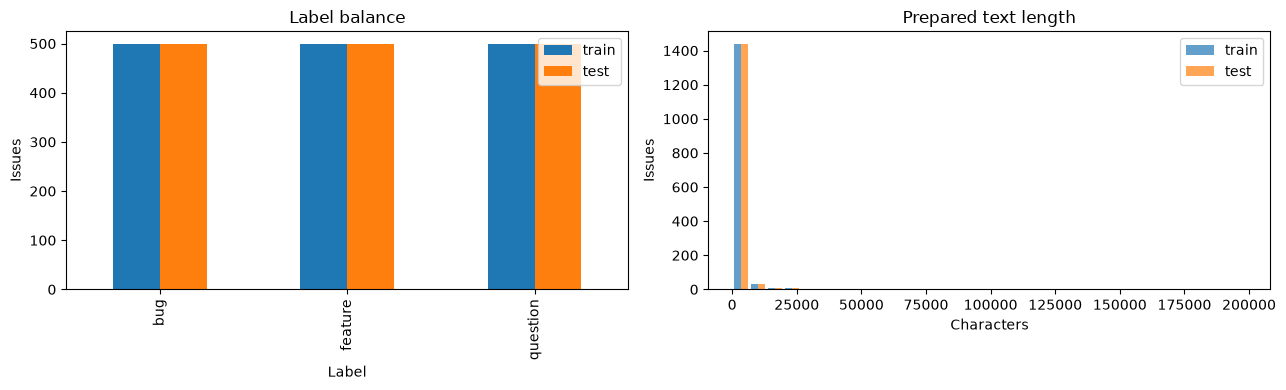

In [6]:
# Step 5: Compare both splits visually before any vectorizer or classifier is fitted.
import os

# Keep Matplotlib's cache inside the project so local and Colab runs stay quiet.
matplotlib_cache = PROJECT_ROOT / ".cache" / "matplotlib"
matplotlib_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(matplotlib_cache))

import matplotlib.pyplot as plt

test_text = build_model_text(test)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.DataFrame(
    {
        "train": inspection["train"]["label_counts"],
        "test": inspection["test"]["label_counts"],
    }
).plot.bar(ax=axes[0], title="Label balance")
axes[0].set(xlabel="Label", ylabel="Issues")

axes[1].hist(
    [train_text.str.len(), test_text.str.len()],
    bins=30,
    label=["train", "test"],
    alpha=0.70,
)
axes[1].set(title="Prepared text length", xlabel="Characters", ylabel="Issues")
axes[1].legend()
fig.tight_layout()
plt.show()
